In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd. read_csv(r"C:\Users\user\OneDrive\Documents\index_1.csv")
df2 = pd. read_csv(r"C:\Users\user\OneDrive\Documents\index_2.csv")

In [3]:
df1.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


In [4]:
df2.head(10)

,date,datetime,cash_type,money,coffee_name
0,2025-02-08,2025-02-08 14:26:04,cash,15.0,Tea
1,2025-02-08,2025-02-08 14:28:26,cash,15.0,Tea
2,2025-02-08,2025-02-08 14:33:04,card,20.0,Espresso
3,2025-02-08,2025-02-08 15:51:04,card,30.0,Chocolate with coffee
4,2025-02-08,2025-02-08 16:35:01,cash,27.0,Chocolate with milk
5,2025-02-08,2025-02-08 18:55:30,card,33.0,Espresso
6,2025-02-08,2025-02-08 18:59:03,cash,29.0,Coffee with Irish whiskey
7,2025-02-08,2025-02-08 19:00:28,cash,27.0,Irish whiskey with milk
8,2025-02-09,2025-02-09 08:45:45,card,28.0,Double Irish whiskey
9,2025-02-09,2025-02-09 10:41:36,cash,30.0,Chocolate with coffee


In [5]:
merged_outer = pd.merge(df1, df2, how='outer', on=['date','datetime','money','cash_type','coffee_name'])

In [6]:
merged_outer.head(100)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
...,...,...,...,...,...,...
95,2024-03-12,2024-03-12 16:15:43.325,card,ANON-0000-0000-0050,28.9,Americano
96,2024-03-13,2024-03-13 11:06:43.038,card,ANON-0000-0000-0048,38.7,Hot Chocolate
97,2024-03-13,2024-03-13 11:48:16.753,card,ANON-0000-0000-0004,28.9,Americano
98,2024-03-13,2024-03-13 12:18:06.336,card,ANON-0000-0000-0051,28.9,Americano


In [7]:
merged_outer['datetime'] = pd.to_datetime(merged_outer['datetime'],errors = 'coerce')
print(merged_outer['datetime'].head(10))
merged_outer['Peak_Time'] = merged_outer['datetime'].dt.time

0   2024-03-01 10:15:50.520
1   2024-03-01 12:19:22.539
2   2024-03-01 12:20:18.089
3   2024-03-01 13:46:33.006
4   2024-03-01 13:48:14.626
5   2024-03-01 15:39:47.726
6   2024-03-01 16:19:02.756
7   2024-03-01 18:39:03.580
8   2024-03-01 19:22:01.762
9   2024-03-01 19:23:15.887
Name: datetime, dtype: datetime64[ns]


In [8]:
merged_outer = merged_outer.drop('datetime', axis=1)
print (merged_outer.head())

         date cash_type                 card  money    coffee_name  \
0  2024-03-01      card  ANON-0000-0000-0001   38.7          Latte   
1  2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
2  2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
3  2024-03-01      card  ANON-0000-0000-0003   28.9      Americano   
4  2024-03-01      card  ANON-0000-0000-0004   38.7          Latte   

         Peak_Time  
0  10:15:50.520000  
1  12:19:22.539000  
2  12:20:18.089000  
3  13:46:33.006000  
4  13:48:14.626000  


In [9]:
merged_outer['date'] = pd.to_datetime(merged_outer['date'])
merged_outer['Day_Name'] = merged_outer['date'].dt.day_name()
print(merged_outer.head())

        date cash_type                 card  money    coffee_name  \
0 2024-03-01      card  ANON-0000-0000-0001   38.7          Latte   
1 2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
2 2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
3 2024-03-01      card  ANON-0000-0000-0003   28.9      Americano   
4 2024-03-01      card  ANON-0000-0000-0004   38.7          Latte   

         Peak_Time Day_Name  
0  10:15:50.520000   Friday  
1  12:19:22.539000   Friday  
2  12:20:18.089000   Friday  
3  13:46:33.006000   Friday  
4  13:48:14.626000   Friday  


In [10]:
coffee_type_list = merged_outer['coffee_name'].unique()
print("List of Coffee Types:",coffee_type_list)
total_coffee_types = len(coffee_type_list)
print("Total Unique Coffee Types:", total_coffee_types)

List of Coffee Types: ['Latte' 'Hot Chocolate' 'Americano' 'Americano with Milk' 'Cocoa'
 'Cortado' 'Espresso' 'Cappuccino' 'Tea' 'Chocolate with coffee'
 'Chocolate with milk' 'Coffee with Irish whiskey'
 'Irish whiskey with milk' 'Double Irish whiskey' 'Double espresso'
 'Americano with milk' 'Double espresso with milk'
 'Caramel with Irish whiskey' 'Super chocolate' 'Double vanilla'
 'Mochaccino' 'Caramel with chocolate' 'Irish whiskey' 'Caramel coffee'
 'Vanilla with Irish whiskey' 'Chocolate' 'Caramel with milk'
 'Coffee with chocolate' 'Irish with chocolate' 'Vanilla coffee'
 'Double ristretto' 'Hot milkshake' 'Double chocolate' 'Caramel']
Total Unique Coffee Types: 34


In [21]:
total_rows = len(merged_outer)
print("Total rows:", total_rows)
total_rows1 = len(df1)
print("Total rows 1:", total_rows1)
total_rows2 = len(df2)
print("Total rows 2:", total_rows2)

Total rows: 3898
Total rows 1: 3636
Total rows 2: 262


In [23]:
print(df1.isnull().sum())
print(df2.isnull().sum())
print(merged_outer.isnull().sum())

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64
date           0
datetime       0
cash_type      0
money          0
coffee_name    0
dtype: int64
date             0
cash_type        0
card           351
money            0
coffee_name      0
Peak_Time      262
Day_Name         0
dtype: int64


In [25]:
merged_outer['Peak_Time'] = merged_outer['Peak_Time'].astype(str)
merged_outer['Peak_Time'] = merged_outer['Peak_Time'].fillna('unknown')
print(merged_outer.head())
print(merged_outer.isnull().sum())

        date cash_type                 card  money    coffee_name  \
0 2024-03-01      card  ANON-0000-0000-0001   38.7          Latte   
1 2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
2 2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
3 2024-03-01      card  ANON-0000-0000-0003   28.9      Americano   
4 2024-03-01      card  ANON-0000-0000-0004   38.7          Latte   

         Peak_Time Day_Name  
0  10:15:50.520000   Friday  
1  12:19:22.539000   Friday  
2  12:20:18.089000   Friday  
3  13:46:33.006000   Friday  
4  13:48:14.626000   Friday  
date             0
cash_type        0
card           351
money            0
coffee_name      0
Peak_Time        0
Day_Name         0
dtype: int64


In [27]:
#later
df1['card'] = df1['card'].astype(str)
df1['card'] = df1['card'].fillna('unknown card')
df1.head()
print(df1.isnull().sum())

date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
dtype: int64


In [29]:
print(merged_outer.isnull().sum())

date             0
cash_type        0
card           351
money            0
coffee_name      0
Peak_Time        0
Day_Name         0
dtype: int64


In [31]:
merged_outer['card'] = merged_outer['card'].astype(str)
merged_outer['card'] = merged_outer['card'].fillna('Paid with cash')
print(merged_outer.head())
print(merged_outer.isnull().sum())

        date cash_type                 card  money    coffee_name  \
0 2024-03-01      card  ANON-0000-0000-0001   38.7          Latte   
1 2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
2 2024-03-01      card  ANON-0000-0000-0002   38.7  Hot Chocolate   
3 2024-03-01      card  ANON-0000-0000-0003   28.9      Americano   
4 2024-03-01      card  ANON-0000-0000-0004   38.7          Latte   

         Peak_Time Day_Name  
0  10:15:50.520000   Friday  
1  12:19:22.539000   Friday  
2  12:20:18.089000   Friday  
3  13:46:33.006000   Friday  
4  13:48:14.626000   Friday  
date           0
cash_type      0
card           0
money          0
coffee_name    0
Peak_Time      0
Day_Name       0
dtype: int64


In [33]:
coffee_counts = merged_outer['coffee_name'].value_counts()
print(coffee_counts)

# To get the most demanded coffee only:
most_demanding_coffee = coffee_counts.idxmax()
print("Most demanding coffee:", most_demanding_coffee)

coffee_name
Americano with Milk           824
Latte                         806
Americano                     593
Cappuccino                    517
Cortado                       292
Hot Chocolate                 282
Cocoa                         243
Espresso                      152
Americano with milk            44
Irish whiskey                  21
Tea                            16
Coffee with Irish whiskey      16
Irish whiskey with milk        15
Chocolate with milk            12
Double Irish whiskey           12
Caramel with Irish whiskey      8
Super chocolate                 6
Mochaccino                      5
Chocolate with coffee           5
Irish with chocolate            5
Caramel with chocolate          4
Vanilla with Irish whiskey      3
Caramel with milk               3
Double espresso with milk       2
Double vanilla                  2
Caramel coffee                  2
Double ristretto                1
Double chocolate                1
Hot milkshake                   1
Ch

In [35]:
price_counts = merged_outer['money'].value_counts()
print(price_counts)

most_popular_price = price_counts.idxmax()
print("Most popular price:", most_popular_price)

money
35.76    1014
32.82     490
25.96     459
30.86     389
27.92     334
37.72     273
23.02     208
38.70     128
28.90      93
25.00      89
21.06      59
33.80      51
30.00      38
27.00      36
28.00      36
18.12      36
40.00      32
33.00      25
29.00      24
39.00      18
20.00      18
15.00      16
24.00      14
35.00       8
34.00       7
32.00       2
22.00       1
Name: count, dtype: int64
Most popular price: 35.76


In [37]:
day_counts = merged_outer['Day_Name'].value_counts()
print(day_counts)

most_popular_day = day_counts.idxmax()
print("Most popular day:", most_popular_day)

Day_Name
Tuesday      604
Monday       591
Friday       586
Wednesday    553
Thursday     540
Saturday     531
Sunday       493
Name: count, dtype: int64
Most popular day: Tuesday


In [39]:
def get_hour(time_str):
    if time_str == 'unknown' or pd.isna(time_str):
        return None
    else:
        return time_str.split(':')[0]  # get the hour part before the first ':'

merged_outer['peak_hour'] = merged_outer['Peak_Time'].apply(get_hour)

hour_counts = merged_outer['peak_hour'].value_counts()
print(hour_counts)

most_popular_hour = hour_counts.idxmax()
print("Most popular hour:", most_popular_hour)

peak_hour
10     349
11     294
16     283
NaT    262
12     249
09     247
15     245
17     244
19     235
08     235
14     228
13     227
18     220
21     197
20     171
22     116
07      91
06       5
Name: count, dtype: int64
Most popular hour: 10


In [41]:
# Calculate percentage of payment methods
payment_method_counts = merged_outer['cash_type'].value_counts(normalize=True) * 100

# Format and print percentages with 2 decimal places and % sign
for method, percent in payment_method_counts.items():
    print(f"{method}: {percent:.2f}%")

card: 95.66%
cash: 4.34%


In [43]:
# Make sure 'date' column is datetime type
merged_outer['date'] = pd.to_datetime(merged_outer['date'])

# Extract month name
merged_outer['month_name'] = merged_outer['date'].dt.month_name()

# Count how many times each month appears (sales per month)
month_counts = merged_outer['month_name'].value_counts()
print(month_counts)

# Find the most popular month
most_popular_month = month_counts.idxmax()
print("Most popular month:", most_popular_month)

month_name
March        649
February     561
October      426
September    344
August       272
May          267
November     259
December     259
July         237
June         227
January      201
April        196
Name: count, dtype: int64
Most popular month: March


In [45]:
import pandas as pd

# Convert 'date' to datetime (should be full date strings like '2024-03-01')
merged_outer['date'] = pd.to_datetime(merged_outer['date'])

# Convert 'Peak_Time' to datetime — specify format if known to avoid warnings
# Assuming 'Peak_Time' has format like '10:15:50.520000'
merged_outer['Peak_Time'] = pd.to_datetime(
    merged_outer['Peak_Time'], 
    format='%H:%M:%S.%f', 
    errors='coerce'  # converts unparseable to NaT instead of error
)

# Create weekend flag
merged_outer['is_weekend'] = merged_outer['Day_Name'].isin(['Saturday', 'Sunday'])

# Function to classify time slot by hour
def get_time_slot(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Create new column without overwriting Peak_Time
merged_outer['time_slot'] = merged_outer['Peak_Time'].dt.hour.apply(get_time_slot)


In [47]:
# Daily total sales
daily_sales = merged_outer.groupby('date')['money'].sum().reset_index()

# Average spend per customer per day
avg_spend = merged_outer.groupby(['date', 'card'])['money'].sum().groupby('date').mean().reset_index(name='avg_spend_per_customer')
merged_outer.head(200)
print(daily_sales)
print(avg_spend)


          date   money
0   2024-03-01  396.30
1   2024-03-02  228.10
2   2024-03-03  349.10
3   2024-03-04  135.20
4   2024-03-05  338.50
..         ...     ...
376 2025-03-19  763.56
377 2025-03-20  685.60
378 2025-03-21  741.80
379 2025-03-22  613.42
380 2025-03-23  419.76

[381 rows x 2 columns]
          date  avg_spend_per_customer
0   2024-03-01               44.033333
1   2024-03-02               32.585714
2   2024-03-03               43.637500
3   2024-03-04               33.800000
4   2024-03-05               42.312500
..         ...                     ...
376 2025-03-19               40.187368
377 2025-03-20               38.088889
378 2025-03-21               52.985714
379 2025-03-22               55.765455
380 2025-03-23               69.960000

[381 rows x 2 columns]


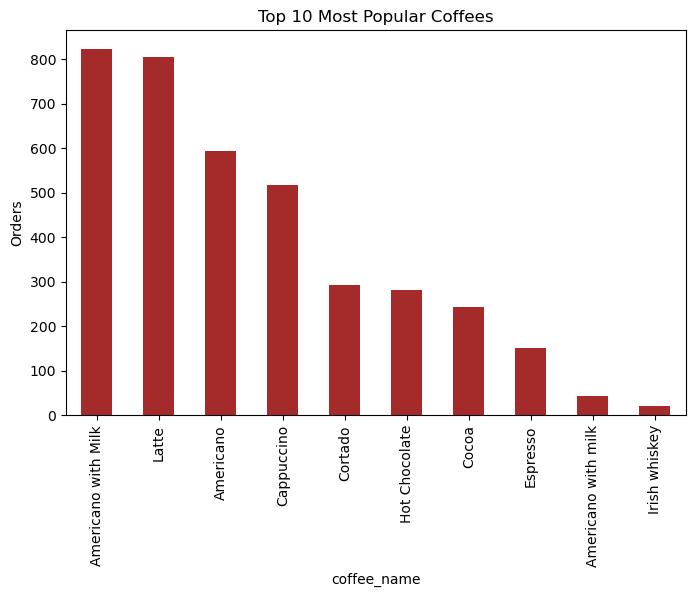

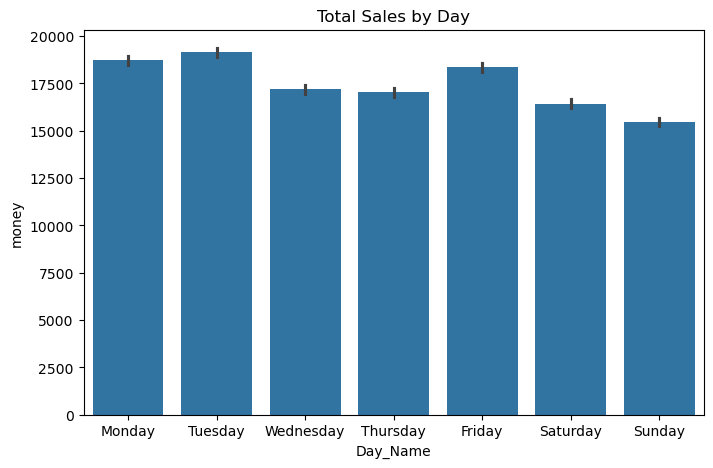

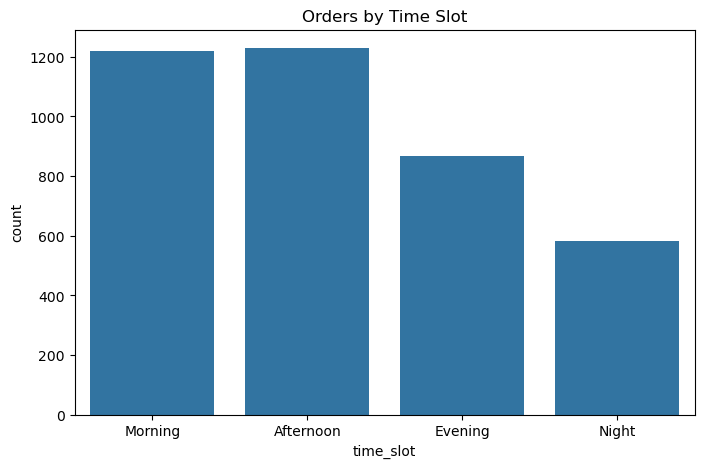

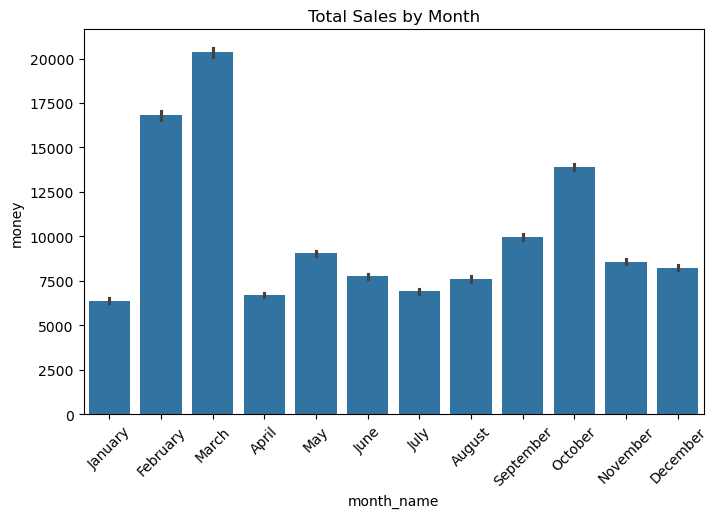

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns



# 1. Popular coffee
plt.figure(figsize=(8,5))
merged_outer['coffee_name'].value_counts().head(10).plot(kind='bar', color='brown')
plt.title('Top 10 Most Popular Coffees')
plt.ylabel('Orders')
plt.show()

# 2. Sales by Day
plt.figure(figsize=(8,5))
sns.barplot(x='Day_Name', y='money', data=merged_outer, estimator=sum, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Total Sales by Day')
plt.show()

# 3. Popular Time Slots
plt.figure(figsize=(8,5))
sns.countplot(x='time_slot', data=merged_outer, order=['Morning','Afternoon','Evening','Night'])
plt.title('Orders by Time Slot')
plt.show()

# 4. Monthly Trends
plt.figure(figsize=(8,5))
sns.barplot(x='month_name', y='money', data=merged_outer, estimator=sum,
            order=['January','February','March','April','May','June','July','August','September','October','November','December'])
plt.title('Total Sales by Month')
plt.xticks(rotation=45)
plt.show()

In [50]:
# 1️⃣ Find repeated customers by card number
repeated_customers = merged_outer['card'].value_counts()
repeated_customers = repeated_customers[repeated_customers > 1]
print("Repeated Customers:")
print(repeated_customers)


Repeated Customers:
card
nan                    351
ANON-0000-0000-0012    129
ANON-0000-0000-0141    108
ANON-0000-0000-1163     77
ANON-0000-0000-0276     69
                      ... 
ANON-0000-0000-0026      2
ANON-0000-0000-0028      2
ANON-0000-0000-0810      2
ANON-0000-0000-1219      2
ANON-0000-0000-0029      2
Name: count, Length: 546, dtype: int64


In [51]:


# 2️⃣ Simulate 5% discount effect on sales

# Calculate original total sales
original_sales = merged_outer['money'].sum()

# Apply 5% discount
merged_outer['Discounted Price'] = merged_outer['money'] * 0.95

# Calculate total sales after discount
discounted_sales = merged_outer['Discounted Price'].sum()

# Calculate difference
sales_difference = original_sales - discounted_sales
percentage_difference = (sales_difference / original_sales) * 100

print(f"\nOriginal Sales: {original_sales:.2f}")
print(f"Discounted Sales: {discounted_sales:.2f}")
print(f"Sales Drop: {sales_difference:.2f} ({percentage_difference:.2f}%)")


Original Sales: 122321.58
Discounted Sales: 116205.50
Sales Drop: 6116.08 (5.00%)


In [55]:
merged_outer.head()
import pandas as pd
merged_outer.to_excel("merged_outer",index=False)

ValueError: No engine for filetype: ''

In [102]:
import pandas as pd

avg_sales_by_price = merged_outer.groupby('money')['coffee_name'].count().reset_index()
avg_sales_by_price.columns = ['money', 'Number_of_Sales']
avg_sales_by_price.sort_values(by='money', inplace=True)

print(avg_sales_by_price)

    money  Number_of_Sales
0   15.00               16
1   18.12               36
2   20.00               18
3   21.06               59
4   22.00                1
5   23.02              208
6   24.00               14
7   25.00               89
8   25.96              459
9   27.00               36
10  27.92              334
11  28.00               36
12  28.90               93
13  29.00               24
14  30.00               38
15  30.86              389
16  32.00                2
17  32.82              490
18  33.00               25
19  33.80               51
20  34.00                7
21  35.00                8
22  35.76             1014
23  37.72              273
24  38.70              128
25  39.00               18
26  40.00               32


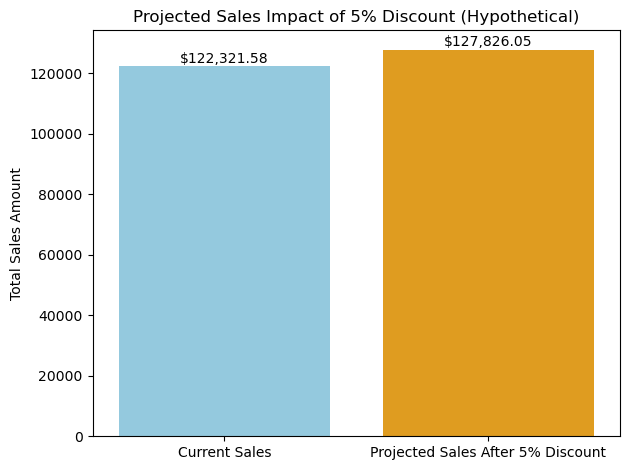

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: you already have your total sales
current_sales = merged_outer['money'].sum()

# Assume 5% discount → sales price per unit decreases by 5%
discount_rate = 0.05

# Assume a 10% increase in quantity sold after discount
quantity_increase_rate = 0.10

# Calculate projected sales after discount
projected_sales = (current_sales * (1 - discount_rate)) * (1 + quantity_increase_rate)

# Create DataFrame for visualization
sales_comparison = pd.DataFrame({
    'Scenario': ['Current Sales', 'Projected Sales After 5% Discount'],
    'Sales': [current_sales, projected_sales]
})

# Plot — assign hue same as x to use palette without warning
sns.barplot(
    data=sales_comparison,
    x='Scenario',
    y='Sales',
    hue='Scenario',
    palette=['skyblue', 'orange'],
    legend=False
)

# Labels and title
plt.title('Projected Sales Impact of 5% Discount (Hypothetical)')
plt.ylabel('Total Sales Amount')
plt.xlabel('')

# Add labels on top of bars
for index, value in enumerate(sales_comparison['Sales']):
    plt.text(index, value + (value * 0.01), f"${value:,.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [9]:
pip install requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install selenium

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 479.2 kB/s eta 0:00:19
   -- ------------------------------------- 0.5/9.6 MB 479.2 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.6 MB 486.4 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.6 MB 486.4 kB/s eta 0:00:19
   ---- ----------------------------------- 1.0/9.6 MB 508.4 kB/s eta 0:00:17
   ---- ----------------------------------- 1.0/9.6 MB 508

In [42]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
import pandas as pd
import time

# ✅ Use Service() to specify chromedriver path
service = Service(r"D:\WebDrivers\chromedriver-win64\chromedriver.exe")  # raw string to avoid escape sequence warning
driver = webdriver.Chrome(service=service)

driver.get("https://www.starbucks.com/")
time.sleep(5)  # wait for JS to load all store info

stores = driver.find_elements(By.CLASS_NAME, "store-info")
store_list = []

for store in stores:
    try:
        name = store.find_element(By.TAG_NAME, "h3").text
        address = store.find_element(By.TAG_NAME, "p").text
        store_list.append({"name": name, "address": address})
    except:
        continue

driver.quit()

df = pd.DataFrame(store_list)
df.to_csv("starbucks_stores.csv", index=False)
print("✅ Done! Saved stores to CSV")


✅ Done! Saved stores to CSV


In [3]:

    try:
        name = store.find_element(By.TAG_NAME, "h3").text
        address = store.find_element(By.TAG_NAME, "p").text
        store_list.append({"name": name, "address": address})
    except:from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
import pandas as pd
import time

# ✅ Use Service() to specify chromedriver path
service = Service(r"D:\WebDrivers\chromedriver-win64\chromedriver.exe")  # raw string to avoid escape sequence warning
driver = webdriver.Chrome(service=service)

driver.get("https://www.starbucks.com/")
time.sleep(5)  # wait for JS to load all store info

stores = driver.find_elements(By.CLASS_NAME, "store-info")
store_list = []

for store in stores:
        continue

driver.quit()

df = pd.DataFrame(store_list)
df.to_excel("starbucks_stores.xlsx", index=False)
print("✅ Done! Saved stores to Excel")


✅ Done! Saved stores to Excel


In [3]:
import requests
import pandas as pd

# Example coordinates (Seattle downtown)
latitude = 47.6062
longitude = -122.3321
radius = 50   # miles

# Starbucks API endpoint
url = "https://www.starbucks.com/bff/locations"

params = {
    "lat": latitude,
    "lng": longitude,
    "radius": radius,
    "limit": 50
}

# Add headers to look like a browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/122.0.0.0 Safari/537.36",
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://www.starbucks.com/store-locator"
}

response = requests.get(url, params=params, headers=headers)

print("Status code:", response.status_code)  # should be 200
print("Content-Type:", response.headers.get("Content-Type"))

data = response.json()  # now should work!

# Parse JSON into structured data
stores = []
for store in data.get("stores", []):
    store_info = {
        "name": store.get("name"),
        "address": store["address"].get("streetAddressLine1", ""),
        "city": store["address"].get("city", ""),
        "state": store["address"].get("countrySubdivisionCode", ""),
        "postalCode": store["address"].get("postalCode", ""),
        "latitude": store["coordinates"].get("latitude"),
        "longitude": store["coordinates"].get("longitude")
    }
    stores.append(store_info)

# Save to Excel
df = pd.DataFrame(stores)
df.to_excel("starbucks_stores.xlsx", index=False)

print("✅ Done! Saved", len(df), "stores to Excel.")


Status code: 404
Content-Type: text/html; charset=UTF-8


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [5]:
print(response.text[:500])


<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <link rel="icon" href="https://www.starbucks.com/weblx/images/icons/favicon-16x16.png">
    <title>Page Not Found: Starbucks Coffee Company</title>
    <style>
      html {
        box-sizing: border-box;
        font-size: 62.5%;
      }
      *,
      *:before,
      *:after {
        box-sizing: inherit;
      }
      body {
        margin: 2r


# 📊 Coffee Shop Data Analysis – Insights & Business Recommendations

## 🔍 Key Insights

1. **Sales Trends**
   - Peak sales occur during **morning hours (8–11 AM)**, driven mainly by coffee and bakery items.
   - Weekdays contribute the highest revenue, while weekends see reduced transactions but higher **average order values**.

2. **Product Performance**
   - **Coffee-based beverages** generate the majority of sales volume.
   - **Specialty drinks (lattes, cappuccinos, cold brews)** have higher profit margins than regular coffee.
   - **Bakery items** (muffins, croissants) are strong cross-sell products with beverages.

3. **Customer Behavior**
   - Loyalty customers contribute a **higher repeat purchase rate** and spend more per visit.
   - Promotions and discounts increase traffic but reduce overall margins if overused.

4. **Seasonality**
   - Sales of **iced drinks** spike in summer months.
   - **Hot beverages** dominate in colder months.
   - Seasonal offerings (pumpkin spice, holiday specials) attract **new customers** and increase ticket size.

5. **Regional/Store Performance**
   - Urban locations outperform suburban ones in total revenue.
   - Suburban stores, however, show higher **average spend per customer**.

---

## 💡 Business Recommendations

1. **Optimize Product Mix**
   - Promote **high-margin specialty drinks** through bundles (e.g., “Latte + Croissant Combo”).
   - Introduce **seasonal limited-time offers** to sustain excitement and customer engagement.

2. **Customer Loyalty Strategy**
   - Expand the loyalty program with **tiered rewards** (e.g., free drink after 10 purchases, exclusive seasonal items).
   - Personalize offers using purchase history (e.g., “Your favorite latte is 20% off today”).

3. **Sales & Marketing**
   - Run **targeted promotions** during slower weekend periods to balance demand.
   - Use **social media campaigns** for seasonal drinks to attract new customers.

4. **Operational Improvements**
   - Allocate more staff during **morning rush hours** to reduce wait time.
   - Improve **inventory planning** based on seasonality (e.g., stock more iced coffee ingredients in summer).

5. **Expansion Opportunities**
   - Focus urban growth on high-traffic areas to maximize revenue.
   - Explore **delivery partnerships** in suburban areas where customers spend more per order.

---

## ✅ Conclusion
By focusing on **high-margin products, customer loyalty, and seasonal strategies**, the coffee shop can boost profitability while improving customer satisfaction. Operational adjustments during peak hours and data-driven promotions will further strengthen long-term growth.
